# Кейс 1 — Анализ эффективности источников трафика

**Контекст:** Media buying / iGaming аналитика  
**Период данных:** Q1–Q2 2024 (январь–июнь)  
**Инструменты:** Python (pandas, matplotlib)  
**Датасет:** `traffic_performance_daily.csv` — 7 644 строки, grain: date × source × campaign × geo

---

## Постановка задачи

Команда медиабаинга закупает трафик через 6 каналов.  
**Вопросы для анализа:**
1. Какой источник приводит больше всего FTD?
2. Где CPA ниже — и означает ли это хорошее качество трафика?
3. Какой источник даёт лучший ROI и наиболее ценных игроков (NGR per FTD)?
4. Где воронка конвертирует лучше — на c2r или r2d?
5. У каких источников сигналы фрода превышают допустимый порог?
6. **Итоговая рекомендация:** Scale / Watch / Hold / Pause по каждому каналу.

---


## 0. Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Стиль графиков
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#F8F9FA',
    'font.family':      'DejaVu Sans',
})

# Цветовая палитра по источникам
COLORS = {
    'Google_Search': '#4285F4',
    'Facebook':      '#1877F2',
    'Native_Ads':    '#FF9500',
    'Push_Network':  '#E53935',
    'TikTok':        '#69C9D0',
    'Affiliate_SEO': '#34A853',
}
SRC_ORDER = ['Google_Search', 'Facebook', 'Affiliate_SEO', 'Native_Ads', 'TikTok', 'Push_Network']


In [2]:
df = pd.read_csv('../data/traffic_performance_daily.csv', parse_dates=['date'])

print(f"Размер датасета: {df.shape}")
print(f"Период: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Источники: {sorted(df['source'].unique())}")
print(f"GEO: {sorted(df['geo'].unique())}")
print(f"\nПропуски (cpc/cpa = 0 у Affiliate_SEO, у которого нет платного spend):")
print(df.isnull().sum()[df.isnull().sum() > 0])


Размер датасета: (7644, 21)
Период: 2024-01-01 → 2024-06-30
Источники: ['Affiliate_SEO', 'Facebook', 'Google_Search', 'Native_Ads', 'Push_Network', 'TikTok']
GEO: ['AU', 'BR', 'CA', 'DE', 'IN', 'NG', 'PL']

Пропуски (cpc/cpa = 0 у Affiliate_SEO, у которого нет платного spend):
cpc        1274
cpa        1499
roi_pct    1274
dtype: int64


In [3]:
# Первичный осмотр
df.head(5)


,date,source,campaign,geo,tier,impressions,clicks,ctr,spend,cpc,...,ftd,c2r,r2d,ngr,cpa,roi_pct,fraud_clicks,fraud_regs,suspicious_ftd,approval_rate
0,2024-01-01,Facebook,FB_Sports_Banner,DE,T1,12632,474,0.0375,120.35,0.254,...,12,0.0949,0.2667,896.24,10.03,644.7,9,0,0,0.971
1,2024-01-01,Facebook,FB_Casino_CreativeA,BR,T2,17022,513,0.0301,48.32,0.094,...,9,0.0838,0.2093,402.16,5.37,732.3,9,0,0,0.965
2,2024-01-01,Facebook,FB_Slots_Video,PL,T2,18947,780,0.0412,74.17,0.095,...,10,0.0795,0.1613,321.55,7.42,333.5,24,0,0,0.975
3,2024-01-01,Facebook,FB_Casino_CreativeA,NG,T3,33066,1516,0.0458,28.20,0.019,...,38,0.0884,0.2836,535.54,0.74,1799.1,57,1,0,0.970
4,2024-01-01,Facebook,FB_Slots_Video,CA,T1,21736,778,0.0358,183.00,0.235,...,13,0.0810,0.2063,971.08,14.08,430.6,18,0,0,0.974


## 1. Агрегация по источникам

In [4]:
agg = df.groupby('source').agg(
    total_spend       = ('spend', 'sum'),
    total_impressions = ('impressions', 'sum'),
    total_clicks      = ('clicks', 'sum'),
    total_regs        = ('registrations', 'sum'),
    total_ftd         = ('ftd', 'sum'),
    total_ngr         = ('ngr', 'sum'),
    total_fraud_clicks= ('fraud_clicks', 'sum'),
    avg_approval_rate = ('approval_rate', 'mean'),
).reset_index()

# Расчёт производных метрик
agg['ctr']           = (agg['total_clicks'] / agg['total_impressions'] * 100).round(2)
agg['cpc']           = (agg['total_spend'] / agg['total_clicks'].replace(0, np.nan)).round(3)
agg['c2r_pct']       = (agg['total_regs'] / agg['total_clicks'] * 100).round(2)
agg['r2d_pct']       = (agg['total_ftd'] / agg['total_regs'].replace(0, np.nan) * 100).round(2)
agg['c2d_pct']       = (agg['total_ftd'] / agg['total_clicks'] * 100).round(3)
agg['cpa']           = (agg['total_spend'] / agg['total_ftd'].replace(0, np.nan)).round(2)
agg['roi_pct']       = ((agg['total_ngr'] - agg['total_spend'])
                         / agg['total_spend'].replace(0, np.nan) * 100).round(1)
agg['roas']          = (agg['total_ngr'] / agg['total_spend'].replace(0, np.nan)).round(3)
agg['ngr_per_ftd']   = (agg['total_ngr'] / agg['total_ftd'].replace(0, np.nan)).round(2)
agg['fraud_rate_pct']= (agg['total_fraud_clicks'] / agg['total_clicks'] * 100).round(2)
agg['avg_approval_rate'] = agg['avg_approval_rate'].round(3)

# Отображение ключевых метрик
display_cols = ['source','total_spend','total_ftd','cpa','roi_pct','roas',
                'ctr','c2r_pct','r2d_pct','ngr_per_ftd','fraud_rate_pct','avg_approval_rate']
agg[display_cols].sort_values('roi_pct', ascending=False).style.background_gradient(
    subset=['roi_pct'], cmap='RdYlGn').format({
    'total_spend': '${:,.0f}', 'cpa': '${:.2f}', 'roi_pct': '{:.0f}%',
    'ngr_per_ftd': '${:.2f}', 'fraud_rate_pct': '{:.1f}%', 'avg_approval_rate': '{:.1%}'
})


,source,total_spend,total_ftd,cpa,roi_pct,roas,ctr,c2r_pct,r2d_pct,ngr_per_ftd,fraud_rate_pct,avg_approval_rate
2,Google_Search,"$506,472",55011,$9.21,560%,6.601000,3.480000,15.000000,29.570000,$60.77,1.0%,99.0%
1,Facebook,"$180,406",25239,$7.15,551%,6.510000,3.540000,8.910000,23.230000,$46.53,3.0%,97.0%
3,Native_Ads,"$100,270",8950,$11.20,244%,3.445000,1.970000,6.980000,18.700000,$38.60,5.9%,94.0%
4,Push_Network,"$32,932",2608,$12.63,64%,1.641000,1.980000,3.920000,9.660000,$20.72,13.9%,86.0%
5,TikTok,"$123,401",6140,$20.10,35%,1.346000,2.020000,5.900000,14.510000,$27.05,7.9%,92.0%
0,Affiliate_SEO,$0,36264,$0.00,nan%,nan,2.000000,21.630000,34.940000,$100.55,1.9%,98.0%


## 2. Визуализация — обзор по 6 метрикам

Шесть графиков показывают источники с разных сторон:

| # | График | Что показывает |
|---|--------|----------------|
| ① | FTD — объём | Сколько игроков приводит каждый канал |
| ② | CPA | Во сколько обходится один FTD |
| ③ | ROI % | Окупаемость рекламных вложений |
| ④ | c2r vs r2d | Где именно конвертирует воронка |
| ⑤ | NGR per FTD | Насколько ценен каждый привлечённый игрок |
| ⑥ | Fraud + Reject rate | Доля некачественного трафика |


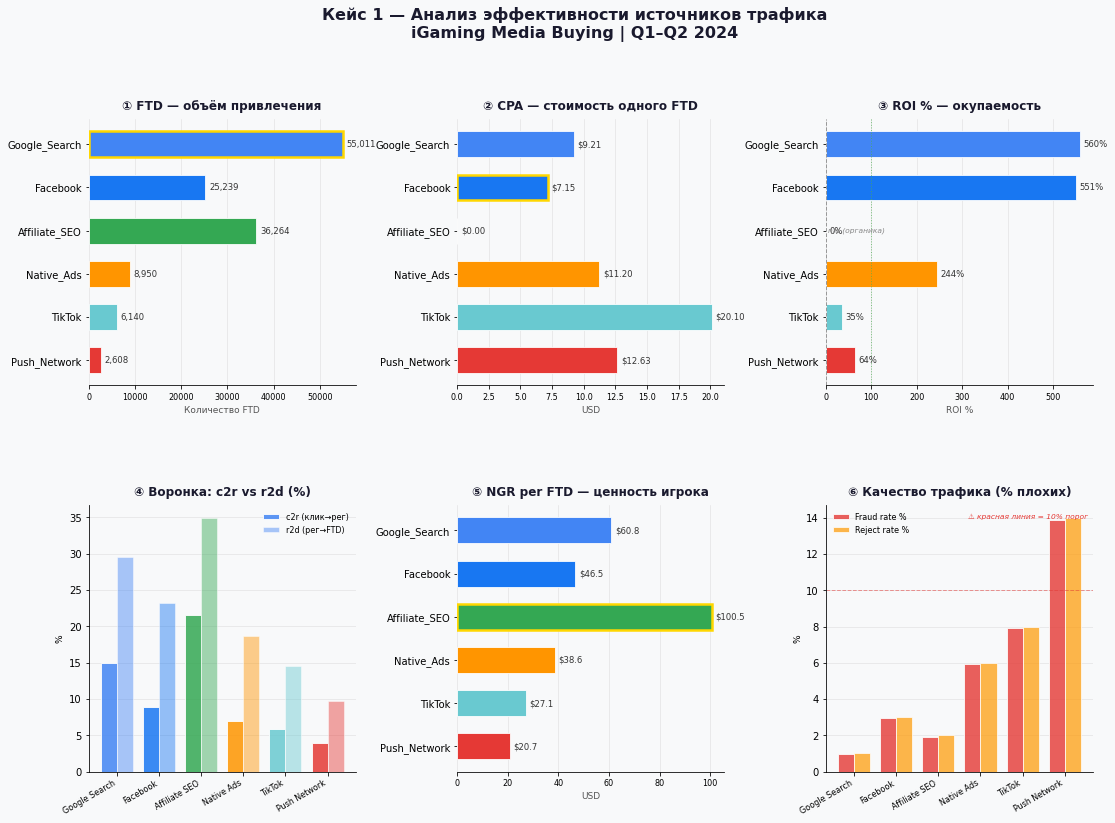

In [5]:
# ── Figure 1: Обзор по 6 метрикам ───────────────────────────────────────────
from matplotlib.gridspec import GridSpec

SRC_ORDER = ['Google_Search','Facebook','Affiliate_SEO','Native_Ads','TikTok','Push_Network']
agg_s     = agg.set_index('source').reindex(SRC_ORDER).reset_index()
palette   = [COLORS[s] for s in SRC_ORDER]

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#F8F9FA')
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

def hbar(ax, vals, labels, colors, title, xlabel, fmt='{}', lo=False, thr=None, thr_lbl=''):
    vs   = [v if not (isinstance(v,float) and np.isnan(v)) else 0 for v in vals]
    bars = ax.barh(labels, vs, color=colors, edgecolor='white', lw=0.8, height=0.6)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10, color='#1A1A2E')
    ax.set_xlabel(xlabel, fontsize=9, color='#555')
    ax.invert_yaxis()
    for sp in ['top','right','left']: ax.spines[sp].set_visible(False)
    ax.set_facecolor('#F8F9FA'); ax.xaxis.grid(True, color='#E0E0E0', lw=0.6); ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=10); ax.tick_params(axis='x', labelsize=8)
    vmax = max(vs) if max(vs) > 0 else 1
    for bar, val, orig in zip(bars, vs, vals):
        lbl = '—' if (isinstance(orig, float) and np.isnan(orig)) else fmt.format(val)
        ax.text(bar.get_width() + vmax*0.015, bar.get_y()+bar.get_height()/2,
                lbl, va='center', ha='left', fontsize=8.5, color='#333')
    if thr:
        ax.axvline(thr, color='#E53935', lw=1.2, ls='--', alpha=0.7)
        if thr_lbl: ax.text(thr*1.01, len(labels)-0.5, thr_lbl, fontsize=7.5,
                            color='#E53935', style='italic')
    valid = [(i,v) for i,v in enumerate(vs) if v > 0]
    if valid:
        bi = min(valid,key=lambda x:x[1])[0] if lo else max(valid,key=lambda x:x[1])[0]
        bars[bi].set_edgecolor('#FFD700'); bars[bi].set_linewidth(2.5)

# ① FTD volume
ax1 = fig.add_subplot(gs[0,0])
hbar(ax1, agg_s['total_ftd'].tolist(), SRC_ORDER, palette,
     '① FTD — объём привлечения', 'Количество FTD', fmt='{:,.0f}')

# ② CPA
ax2 = fig.add_subplot(gs[0,1])
hbar(ax2, agg_s['cpa'].tolist(), SRC_ORDER, palette,
     '② CPA — стоимость одного FTD', 'USD', fmt='${:.2f}', lo=True)

# ③ ROI%
ax3 = fig.add_subplot(gs[0,2])
rv    = agg_s['roi_pct'].fillna(0).tolist()
bars3 = ax3.barh(SRC_ORDER, rv, color=palette, edgecolor='white', lw=0.8, height=0.6)
ax3.set_title('③ ROI % — окупаемость', fontsize=12, fontweight='bold', pad=10, color='#1A1A2E')
ax3.set_xlabel('ROI %', fontsize=9, color='#555'); ax3.invert_yaxis()
ax3.axvline(0, color='#999', lw=1, ls='--')
ax3.axvline(100, color='#4CAF50', lw=1, ls=':', alpha=0.7)
for sp in ['top','right','left']: ax3.spines[sp].set_visible(False)
ax3.set_facecolor('#F8F9FA'); ax3.xaxis.grid(True,color='#E0E0E0',lw=0.6); ax3.set_axisbelow(True)
ax3.tick_params(axis='y', labelsize=10); ax3.tick_params(axis='x', labelsize=8)
for bar, val in zip(bars3, rv):
    ax3.text(bar.get_width()+8, bar.get_y()+bar.get_height()/2,
             f'{val:.0f}%', va='center', ha='left', fontsize=8.5, color='#333')
# Affiliate_SEO note
idx_seo = SRC_ORDER.index('Affiliate_SEO')
ax3.text(5, idx_seo, 'n/a (органика)', va='center', fontsize=7.5, color='#888', style='italic')

# ④ Воронка c2r vs r2d
ax4 = fig.add_subplot(gs[1,0])
x = np.arange(len(SRC_ORDER)); w = 0.38
ax4.bar(x-w/2, agg_s['c2r_pct'], width=w, color=palette, alpha=0.85,
        label='c2r (клик→рег)', edgecolor='white')
ax4.bar(x+w/2, agg_s['r2d_pct'], width=w, color=palette, alpha=0.45,
        label='r2d (рег→FTD)', edgecolor='white')
ax4.set_title('④ Воронка: c2r vs r2d (%)', fontsize=12, fontweight='bold', pad=10, color='#1A1A2E')
ax4.set_xticks(x); ax4.set_xticklabels([s.replace('_',' ') for s in SRC_ORDER],
                                          rotation=30, ha='right', fontsize=8)
ax4.set_ylabel('%', fontsize=9)
for sp in ['top','right']: ax4.spines[sp].set_visible(False)
ax4.set_facecolor('#F8F9FA'); ax4.yaxis.grid(True,color='#E0E0E0',lw=0.6); ax4.set_axisbelow(True)
ax4.legend(fontsize=8, framealpha=0)

# ⑤ NGR per FTD
ax5 = fig.add_subplot(gs[1,1])
hbar(ax5, agg_s['ngr_per_ftd'].tolist(), SRC_ORDER, palette,
     '⑤ NGR per FTD — ценность игрока', 'USD', fmt='${:.1f}')

# ⑥ Fraud rate + Reject rate
ax6 = fig.add_subplot(gs[1,2])
reject_vals = ((1 - agg_s['avg_approval_rate']) * 100).tolist()
x6 = np.arange(len(SRC_ORDER))
ax6.bar(x6-w/2, agg_s['fraud_rate_pct'], width=w, color='#E53935', alpha=0.8,
        label='Fraud rate %', edgecolor='white')
ax6.bar(x6+w/2, reject_vals, width=w, color='#FF9800', alpha=0.7,
        label='Reject rate %', edgecolor='white')
ax6.axhline(10, color='#E53935', lw=1, ls='--', alpha=0.5)
ax6.set_title('⑥ Качество трафика (% плохих)', fontsize=12, fontweight='bold', pad=10, color='#1A1A2E')
ax6.set_xticks(x6); ax6.set_xticklabels([s.replace('_',' ') for s in SRC_ORDER],
                                          rotation=30, ha='right', fontsize=8)
ax6.set_ylabel('%', fontsize=9)
for sp in ['top','right']: ax6.spines[sp].set_visible(False)
ax6.set_facecolor('#F8F9FA'); ax6.yaxis.grid(True,color='#E0E0E0',lw=0.6); ax6.set_axisbelow(True)
ax6.legend(fontsize=8, framealpha=0)
ax6.text(0.98, 0.97, '⚠ красная линия = 10% порог', transform=ax6.transAxes,
         fontsize=7.5, ha='right', va='top', color='#E53935', style='italic')

fig.suptitle('Кейс 1 — Анализ эффективности источников трафика\niGaming Media Buying | Q1–Q2 2024',
             fontsize=16, fontweight='bold', color='#1A1A2E', y=1.01)
plt.tight_layout()
plt.show()


## 3. Динамика метрик по неделям

In [6]:
df['week'] = df['date'].dt.to_period('W').apply(lambda p: p.start_time)

weekly = df.groupby(['week', 'source']).agg(
    ftd   = ('ftd',   'sum'),
    spend = ('spend', 'sum'),
    ngr   = ('ngr',   'sum'),
).reset_index()

weekly['cpa'] = (weekly['spend'] / weekly['ftd'].replace(0, np.nan)).round(2)
weekly['roi'] = ((weekly['ngr'] - weekly['spend'])
                  / weekly['spend'].replace(0, np.nan) * 100).round(1)

# Пример вывода топ-недель по FTD для Google_Search
weekly[weekly['source']=='Google_Search'].nlargest(5, 'ftd')[['week','ftd','cpa','roi']]


,week,ftd,cpa,roi
128,2024-05-27,2661,9.84,564.5
92,2024-04-15,2405,8.62,606.9
122,2024-05-20,2259,8.38,583.3
8,2024-01-08,2233,8.93,578.8
74,2024-03-25,2233,8.98,601.6


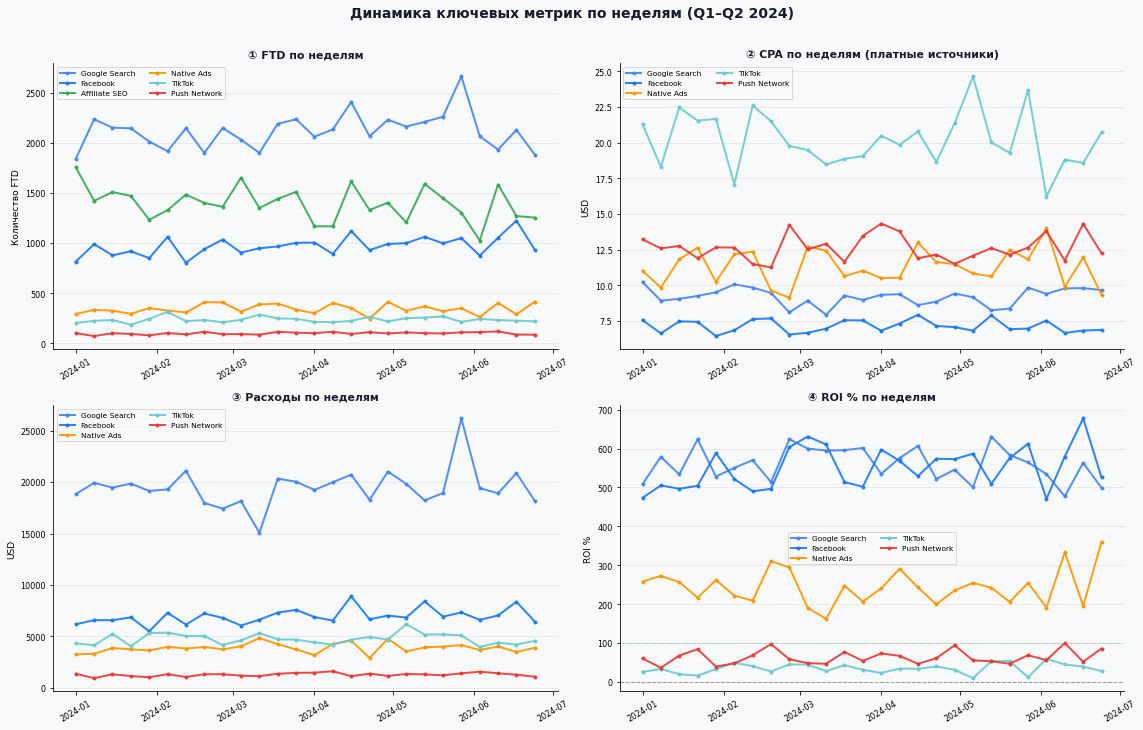

In [7]:
# ── Figure 2: Динамика по неделям ────────────────────────────────────────────
paid_src = [s for s in SRC_ORDER if s != 'Affiliate_SEO']

fig2, axes = plt.subplots(2, 2, figsize=(16, 10))
fig2.patch.set_facecolor('#F8F9FA')
fig2.suptitle('Динамика ключевых метрик по неделям (Q1–Q2 2024)',
              fontsize=14, fontweight='bold', color='#1A1A2E', y=1.01)

for ax, (metric, title, ylabel, use_paid) in zip(axes.flat, [
    ('ftd',   '① FTD по неделям',                      'Количество FTD', False),
    ('cpa',   '② CPA по неделям (платные источники)',   'USD',            True),
    ('spend', '③ Расходы по неделям',                   'USD',            True),
    ('roi',   '④ ROI % по неделям',                     'ROI %',          True),
]):
    src_list = paid_src if use_paid else SRC_ORDER
    for src in src_list:
        sub = weekly[weekly['source'] == src].sort_values('week')
        if sub[metric].isna().all(): continue
        ax.plot(sub['week'], sub[metric], marker='o', markersize=3,
                lw=2, color=COLORS[src], label=src.replace('_',' '), alpha=0.9)
    if metric == 'roi':
        ax.axhline(0,   color='#999', lw=1, ls='--')
        ax.axhline(100, color='#4CAF50', lw=1, ls=':', alpha=0.6)
    ax.set_title(title, fontsize=11, fontweight='bold', color='#1A1A2E')
    ax.set_ylabel(ylabel, fontsize=9)
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True,color='#E0E0E0',lw=0.6); ax.set_axisbelow(True)
    ax.tick_params(axis='x', rotation=30, labelsize=8); ax.tick_params(axis='y', labelsize=8)
    ax.legend(fontsize=7.5, framealpha=0.7, ncol=2)

plt.tight_layout()
plt.show()


## 4. Позиционирование источников и сравнение воронки

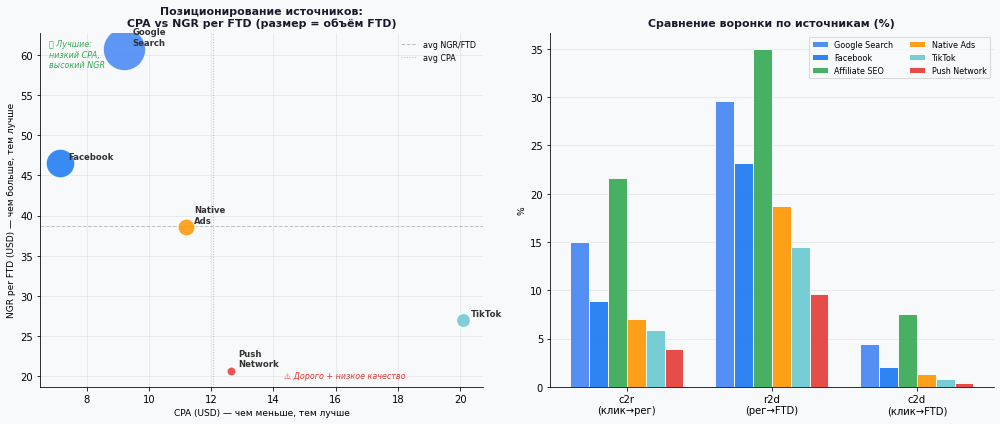

In [8]:
# ── Figure 3: Scatter CPA vs NGR/FTD + сравнение воронки ─────────────────────
agg_paid = agg[agg['source'] != 'Affiliate_SEO'].copy()

fig3, axes = plt.subplots(1, 2, figsize=(14, 6))
fig3.patch.set_facecolor('#F8F9FA')

# Left: scatter
ax = axes[0]
for _, row in agg_paid.iterrows():
    s = row['source']
    ax.scatter(row['cpa'], row['ngr_per_ftd'],
               s=row['total_ftd'] / 30,
               color=COLORS[s], alpha=0.85, edgecolors='white', linewidth=1.5, zorder=3)
    ax.annotate(s.replace('_','\n'), (row['cpa'], row['ngr_per_ftd']),
                textcoords='offset points', xytext=(8, 4),
                fontsize=8.5, color='#333', fontweight='bold')

ax.axhline(agg_paid['ngr_per_ftd'].mean(), color='#999', lw=1, ls='--', alpha=0.6, label='avg NGR/FTD')
ax.axvline(agg_paid['cpa'].mean(),         color='#999', lw=1, ls=':', alpha=0.6, label='avg CPA')
ax.set_title('Позиционирование источников:\nCPA vs NGR per FTD (размер = объём FTD)',
             fontsize=11, fontweight='bold', color='#1A1A2E')
ax.set_xlabel('CPA (USD) — чем меньше, тем лучше', fontsize=9)
ax.set_ylabel('NGR per FTD (USD) — чем больше, тем лучше', fontsize=9)
ax.text(0.02, 0.98, '🏆 Лучшие:\nнизкий CPA,\nвысокий NGR',
        transform=ax.transAxes, fontsize=8, va='top', color='#34A853', style='italic')
ax.text(0.55, 0.02, '⚠ Дорого + низкое качество',
        transform=ax.transAxes, fontsize=8, va='bottom', color='#E53935', style='italic')
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.set_facecolor('#F8F9FA'); ax.grid(color='#E0E0E0', lw=0.6); ax.set_axisbelow(True)
ax.legend(fontsize=8, framealpha=0)

# Right: funnel bar chart
ax2 = axes[1]
funnel_metrics = ['c2r_pct', 'r2d_pct', 'c2d_pct']
funnel_labels  = ['c2r\n(клик→рег)', 'r2d\n(рег→FTD)', 'c2d\n(клик→FTD)']
x  = np.arange(len(funnel_labels))
w  = 0.13
for i, src in enumerate(SRC_ORDER):
    row  = agg[agg['source'] == src].iloc[0]
    vals = [row['c2r_pct'], row['r2d_pct'], row['c2d_pct']]
    ax2.bar(x + i*w - w*2.5, vals, width=w, color=COLORS[src],
            label=src.replace('_',' '), edgecolor='white', alpha=0.9)
ax2.set_title('Сравнение воронки по источникам (%)', fontsize=11, fontweight='bold', color='#1A1A2E')
ax2.set_xticks(x); ax2.set_xticklabels(funnel_labels, fontsize=10)
ax2.set_ylabel('%', fontsize=9)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)
ax2.set_facecolor('#F8F9FA'); ax2.yaxis.grid(True,color='#E0E0E0',lw=0.6); ax2.set_axisbelow(True)
ax2.legend(fontsize=8, framealpha=0.7, ncol=2)

plt.tight_layout()
plt.show()


## 5. Итоговые решения по каждому источнику

In [9]:
# Правило принятия решений
def decide(row):
    fraud = row['fraud_rate_pct']
    appr  = row['avg_approval_rate']
    roi   = row['roi_pct'] if not np.isnan(row['roi_pct']) else 999
    r2d   = row['r2d_pct']
    if row['source'] == 'Affiliate_SEO':
        return 'SCALE'   # органика без прямых затрат — всегда масштабируем SEO
    if fraud > 10 or appr < 0.80:
        return 'PAUSE'   # фрод или оператор отклоняет > 20% — стоп
    if roi > 200 and fraud < 5 and r2d > 20:
        return 'SCALE'   # отличный ROI + качество
    if roi > 50 or (roi > 0 and fraud < 8):
        return 'WATCH'   # окупается, но следим
    return 'HOLD'        # не окупается, не масштабируем

agg_s = agg.set_index('source').loc[SRC_ORDER].reset_index()
agg_s['decision'] = agg_s.apply(decide, axis=1)

agg_s[['source','total_ftd','cpa','roi_pct','ngr_per_ftd',
       'fraud_rate_pct','avg_approval_rate','decision']]


,source,total_ftd,cpa,roi_pct,ngr_per_ftd,fraud_rate_pct,avg_approval_rate,decision
0,Google_Search,55011,9.21,560.1,60.77,0.96,0.99,SCALE
1,Facebook,25239,7.15,551.0,46.53,2.95,0.97,SCALE
2,Affiliate_SEO,36264,0.00,NaN,100.55,1.90,0.98,SCALE
3,Native_Ads,8950,11.20,244.5,38.60,5.93,0.94,WATCH
4,TikTok,6140,20.10,34.6,27.05,7.94,0.92,WATCH
5,Push_Network,2608,12.63,64.1,20.72,13.91,0.86,PAUSE


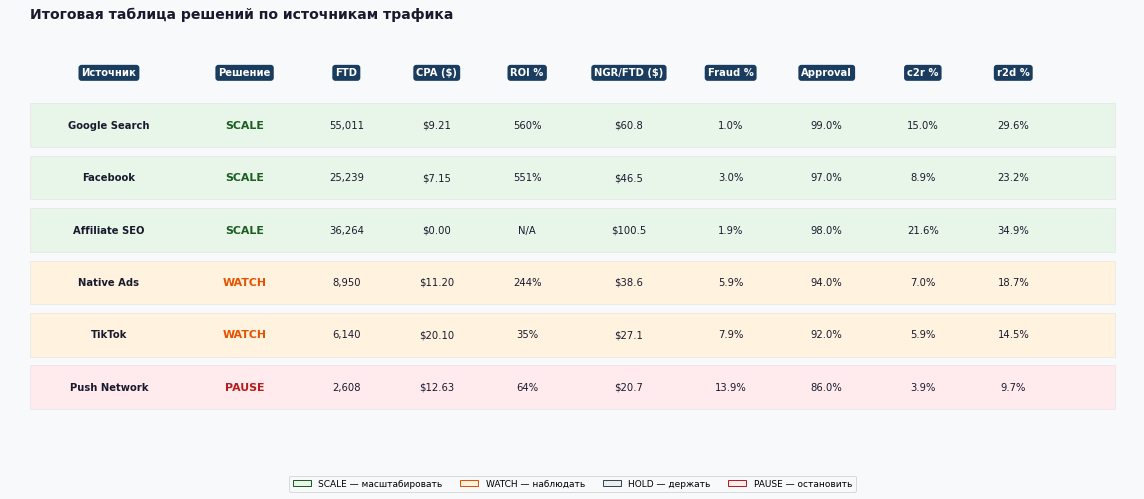

In [10]:
# ── Figure 4: Таблица решений ────────────────────────────────────────────────
import matplotlib.patches as mpatches

fig4, ax = plt.subplots(figsize=(16, 7))
fig4.patch.set_facecolor('#F8F9FA')
ax.axis('off')

agg_s2 = agg.set_index('source').reindex(SRC_ORDER).reset_index()

def get_decision(row):
    fraud = row['fraud_rate_pct']
    appr  = row['avg_approval_rate']
    roi   = row['roi_pct'] if not (isinstance(row['roi_pct'], float) and np.isnan(row['roi_pct'])) else 999
    r2d   = row['r2d_pct']
    if row['source'] == 'Affiliate_SEO':
        return 'SCALE',  '#1B5E20', '#E8F5E9'
    if fraud > 10 or appr < 0.80:
        return 'PAUSE',  '#B71C1C', '#FFEBEE'
    if roi > 200 and fraud < 5 and r2d > 20:
        return 'SCALE',  '#1B5E20', '#E8F5E9'
    if roi > 50 or (roi > 0 and fraud < 8):
        return 'WATCH',  '#E65100', '#FFF3E0'
    return     'HOLD',   '#37474F', '#ECEFF1'

col_headers = ['Источник','Решение','FTD','CPA ($)','ROI %',
               'NGR/FTD ($)','Fraud %','Approval','c2r %','r2d %']
col_widths  = [0.14, 0.10, 0.08, 0.08, 0.08, 0.10, 0.08, 0.09, 0.08, 0.08]

# Header
x = 0.02
for h, w in zip(col_headers, col_widths):
    ax.text(x + w/2, 0.92, h, ha='center', va='center', fontsize=10, fontweight='bold',
            color='white', bbox=dict(boxstyle='round,pad=0.3', facecolor='#1A3C5E', edgecolor='none'))
    x += w

# Rows
for i, (_, row) in enumerate(agg_s2.iterrows()):
    dec, tc, bc = get_decision(row)
    y = 0.80 - i*0.12
    ax.add_patch(plt.Rectangle((0.02, y-0.05), 0.96, 0.10,
                                facecolor=bc, edgecolor='#E0E0E0', lw=0.5))
    cpa_v = row['cpa'];  roi_v = row['roi_pct']
    vals = [
        row['source'].replace('_',' '),
        dec,
        f"{row['total_ftd']:,.0f}",
        f"${cpa_v:.2f}"   if not (isinstance(cpa_v, float)  and np.isnan(cpa_v))  else '—',
        f"{roi_v:.0f}%"   if not (isinstance(roi_v, float)  and np.isnan(roi_v))  else 'N/A',
        f"${row['ngr_per_ftd']:.1f}",
        f"{row['fraud_rate_pct']:.1f}%",
        f"{row['avg_approval_rate']:.1%}",
        f"{row['c2r_pct']:.1f}%",
        f"{row['r2d_pct']:.1f}%",
    ]
    x = 0.02
    for j, (val, w) in enumerate(zip(vals, col_widths)):
        color  = tc if j == 1 else '#1A1A2E'
        weight = 'bold' if j in (0,1) else 'normal'
        ax.text(x + w/2, y, val, ha='center', va='center',
                fontsize=10 if j != 1 else 11, fontweight=weight, color=color)
        x += w

ax.set_title('Итоговая таблица решений по источникам трафика',
             fontsize=14, fontweight='bold', color='#1A1A2E', pad=20, loc='left', x=0.02)

legend_items = [
    mpatches.Patch(facecolor='#E8F5E9', edgecolor='#1B5E20', label='SCALE — масштабировать'),
    mpatches.Patch(facecolor='#FFF3E0', edgecolor='#E65100', label='WATCH — наблюдать'),
    mpatches.Patch(facecolor='#ECEFF1', edgecolor='#37474F', label='HOLD — держать'),
    mpatches.Patch(facecolor='#FFEBEE', edgecolor='#B71C1C', label='PAUSE — остановить'),
]
ax.legend(handles=legend_items, loc='lower center', bbox_to_anchor=(0.5, -0.05),
          ncol=4, fontsize=9, framealpha=0.7)
plt.tight_layout()
plt.show()


## 6. Выводы и рекомендации

### 🏆 Итог по источникам

| Источник | Решение | Обоснование |
|---|---|---|
| **Google_Search** | 🚀 SCALE | Лучший ROI среди платных (~560%). Высокий r2d=29.6%, NGR/FTD=$60.8. CPA выше, но окупается. |
| **Facebook** | 🚀 SCALE | Хороший ROI (~551%), умеренный fraud=3%. Второй по объёму FTD. |
| **Affiliate_SEO** | 🚀 SCALE | Нет прямых затрат, лучший r2d=34.9% и NGR/FTD=$100+. Инвестировать в контент. |
| **Native_Ads** | 🔍 WATCH | ROI~244% — окупается, но fraud=5.9%. Оптимизировать площадки. |
| **TikTok** | 🔍 WATCH | ROI~35% невысокий, fraud=7.9%. Тестировать новые креативы. |
| **Push_Network** | 🛑 PAUSE | Fraud=13.9%, approval_rate=0.86. Почти каждый 7-й клик — фрод. ROI при реальном качестве уходит в минус. |

---

### Ключевые инсайты

**1. Дешёвый CPA ≠ хорошее качество.**  
Push_Network даёт самый дешёвый CPA ($12.6), но fraud_rate 13.9% и approval_rate 86% означают,  
что реальная стоимость качественного FTD значительно выше.

**2. Google_Search — самый эффективный платный источник.**  
CPA выше ($9.2), но r2d=29.6% и NGR/FTD=$60.8 делают его лучшим по окупаемости.

**3. Affiliate_SEO — золотой стандарт качества.**  
Нет прямых затрат, r2d=34.9% — каждый третий зарегистрированный делает депозит.  
Это в 3.6× лучше, чем Push_Network.

**4. Воронка Push_Network проседает на r2d.**  
c2r=3.9% — низкий, но r2d=9.7% — катастрофический. Аудитория не конвертируется в депозит.

---

### Следующие шаги
- **Push_Network:** запросить у оператора детализацию по rejection reasons. Рассмотреть полное отключение.
- **TikTok:** A/B тест новых креативов. Сравнить r2d по кампаниям — возможно, проблема в одной.
- **Google_Search + Facebook:** увеличить бюджет на 15-20% в T1 GEO (DE, CA, AU).
- **Affiliate_SEO:** инвестировать в link building и новые review-страницы.

---

*Анализ выполнен в рамках проекта [traffic-analyst-portfolio](https://github.com/timofeymmedvedev)*  
*Датасет: синтетические данные, моделирующие реальную среду media buying / iGaming*
